<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi04/blob/main/CNN_VD01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd                          # đọc file CSV
import numpy as np                           # tính toán ma trận
import tensorflow as tf                      # framework deep learning
import keras                                 # API cấp cao xây mô hình
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten  # các tầng CNN
from keras.models import Sequential          # mô hình xếp chồng tầng
from keras import Input                      # định nghĩa shape đầu vào
import matplotlib.pyplot as plt              # vẽ biểu đồ / hiển thị ảnh


In [ ]:
##Doc Data
mnist_train = '/content/sample_data/mnist_train.csv'
mnist_test  = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)          # đọc file CSV train
df_test  = pd.read_csv(mnist_test)           # đọc file CSV test

print(df_train.shape)                        # kiểm tra kích thước: (60000, 785)

X_train = df_train.iloc[:, 1:]              # lấy cột 1→784 (pixel), bỏ cột nhãn
y_train = df_train.iloc[:, 0]               # lấy cột 0 (nhãn 0-9)
X_test  = df_test.iloc[:, 1:]
y_test  = df_test.iloc[:, 0]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
# (60000, 784) (60000,) (10000, 784) (10000,)



(60000, 785)
(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:

num_classes = 10                             # 10 chữ số 0-9
input_shape = (28, 28, 1)                   # CNN cần ảnh dạng (cao, rộng, kênh màu)

X_train = X_train.astype("float32") / 255   # normalize pixel [0,255] → [0,1]
X_test  = X_test.astype("float32")  / 255

X_train = X_train.to_numpy()                # chuyển DataFrame → numpy array
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)  # (60000,784) → (60000,28,28,1)
print(X_train.shape)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))  # = 10
print('Classes:', np.unique(y_train))                 # [0 1 2 3 4 5 6 7 8 9]
print(y_train[:5])                                    # xem 5 nhãn đầu

(60000, 28, 28, 1)
(10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    0
2    4
3    1
4    9
Name: label, dtype: int64


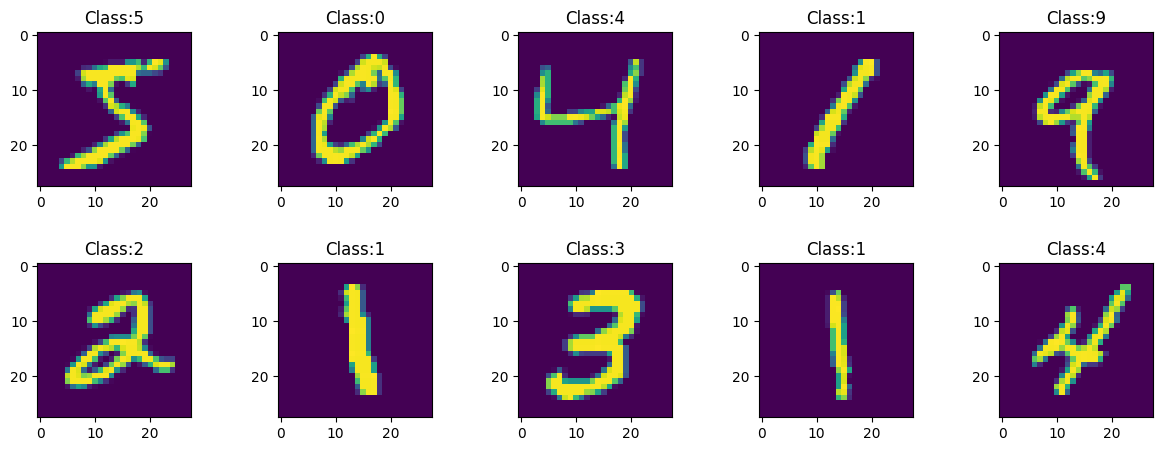

In [ ]:
##Trực quan hóa 10 ảnh đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))  # lưới 2 hàng × 5 cột
ax = axes.ravel()                            # chuyển mảng 2D → 1D cho dễ dùng vòng lặp

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28)) # hiển thị ảnh 28×28
    ax[i].set_title('Class:' + str(y_train[i]))  # tiêu đề = nhãn

plt.subplots_adjust(hspace=0.5)             # tăng khoảng cách giữa các hàng
plt.show()

In [ ]:
#Chuyen nhan thành vector nhị phân

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test,  num_classes)


In [ ]:
#Build
model = Sequential()                         # khởi tạo mô hình tuần tự
model.add(Input(shape=input_shape))          # đầu vào: ảnh 28×28×1

# Conv Block 1: trích xuất đặc trưng cơ bản (cạnh, góc...)
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
# → output: (26, 26, 32) — 32 bản đồ đặc trưng, ReLU loại giá trị âm

model.add(MaxPool2D(pool_size=(2, 2)))
# → output: (13, 13, 32) — giảm kích thước ÷2, giữ đặc trưng quan trọng

# Conv Block 2: trích xuất đặc trưng phức tạp hơn
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
# → output: (11, 11, 64)

model.add(MaxPool2D(pool_size=(2, 2)))
# → output: (5, 5, 64)

model.add(Flatten())
# → output: 1600 — chuyển ma trận 3D thành vector 1D để đưa vào Dense

model.add(Dense(units=10, activation='softmax'))
# → output: 10 — xác suất cho 10 chữ số, tổng = 1

model.summary()                              # in bảng tóm tắt kiến trúc

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
##Côpile & huấn luyện
model.compile(
    optimizer='adam',                        # thuật toán tối ưu học thích nghi
    loss='categorical_crossentropy',         # loss cho bài toán nhiều lớp (đã one-hot)
    metrics=['accuracy']                     # theo dõi độ chính xác khi train
)

model_fit = model.fit(
    X_train, y_train,
    batch_size=128,                          # cập nhật trọng số sau mỗi 128 ảnh
    epochs=15,                               # lặp toàn bộ dữ liệu 15 lần
    validation_split=0.1,                    # dùng 10% train làm validation
    verbose=1                                # hiển thị tiến trình
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.9206 - loss: 0.2870 - val_accuracy: 0.9772 - val_loss: 0.0877
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9772 - loss: 0.0749 - val_accuracy: 0.9833 - val_loss: 0.0635
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.9830 - loss: 0.0555 - val_accuracy: 0.9867 - val_loss: 0.0503
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9860 - loss: 0.0457 - val_accuracy: 0.9878 - val_loss: 0.0450
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.9867 - val_loss: 0.0443
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9899 - loss: 0.0331 - val_accuracy: 0.9862 - val_loss: 0.0537
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9907 - loss: 0.0302 - val_accuracy: 0.9848 - val_loss: 0.0553
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.9920 - loss: 0.0259 -

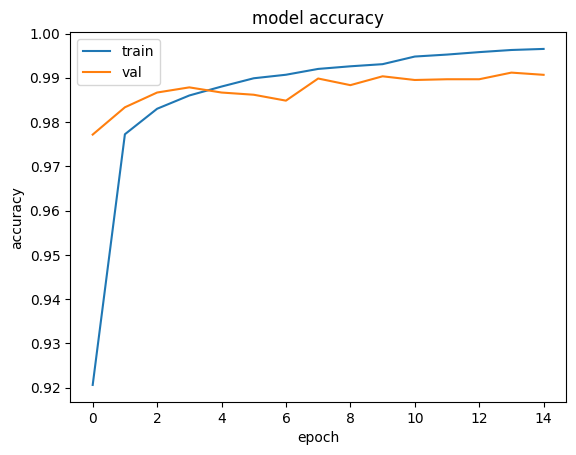

In [ ]:
#Accuracy

plt.plot(model_fit.history['accuracy'])      # accuracy trên tập train
plt.plot(model_fit.history['val_accuracy'])  # accuracy trên tập validation
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# Nếu train >> val → overfitting; nếu cả 2 tăng đều → tốt

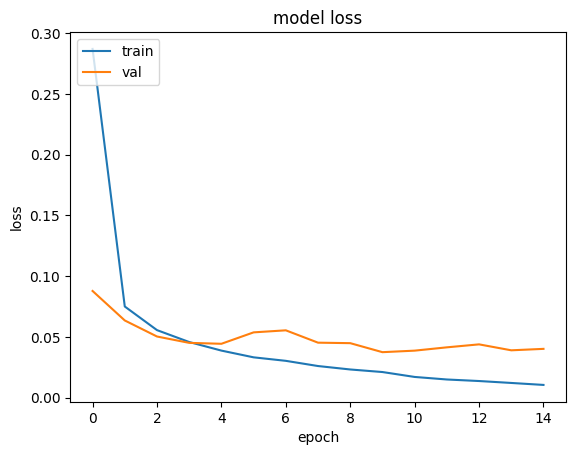

313/313 - 3s - 10ms/step - accuracy: 0.9904 - loss: 0.0344
Test loss:     0.03439144045114517
Test accuracy: 0.9904000163078308


In [ ]:
#Loss trên test
plt.plot(model_fit.history['loss'])          # loss trên tập train
plt.plot(model_fit.history['val_loss'])      # loss trên tập validation
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

score = model.evaluate(X_test, y_test, verbose=2)  # đánh giá trên test set
print('Test loss:    ', score[0])            # loss cuối cùng (~0.034)
print('Test accuracy:', score[1])            # accuracy (~99%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


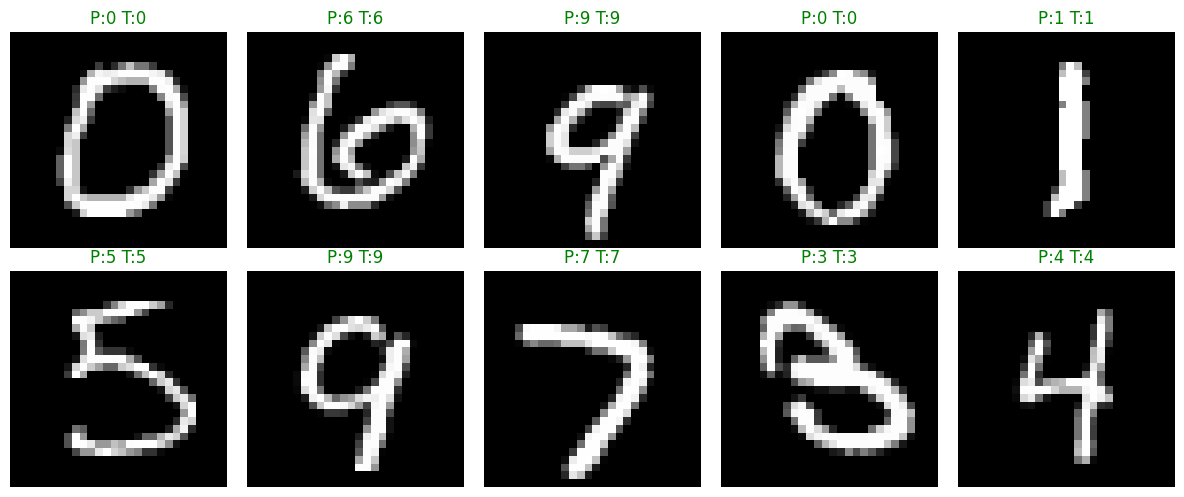

In [ ]:
#Du bao hiển thị kết quả
start, end = 10, 20
predictions = model.predict(X_test[start:end])  # dự báo 10 ảnh từ vị trí 10-20

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test[start+i].reshape(28, 28), cmap='gray')  # hiển thị ảnh
    pred = np.argmax(predictions[i])         # lấy class có xác suất cao nhất
    true = np.argmax(y_test[start+i])        # nhãn thực (đã one-hot → argmax)
    color = 'green' if pred == true else 'red'  # xanh = đúng, đỏ = sai
    ax.set_title(f'P:{pred} T:{true}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Luu mo hinh

model.save_weights('cnn_mnist.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[9.6158801e-12 4.7863946e-10 9.9999988e-01 2.0554724e-13 3.0328308e-16
  1.1153490e-18 1.7671003e-07 1.7853544e-14 8.9326324e-10 3.3865296e-13]]
2 2


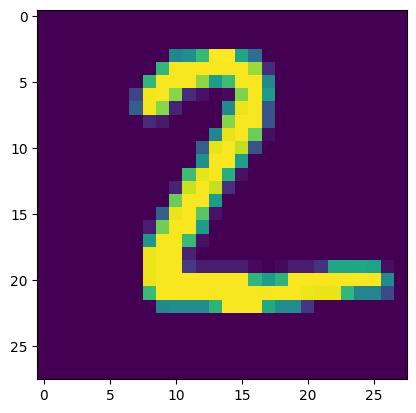

In [ ]:
##Nạp lại mô hình và dự báo

model2 = Sequential()
model2.add(Input(shape=input_shape))
model2.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model2.add(MaxPool2D(pool_size=(2, 2)))
model2.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model2.add(MaxPool2D(pool_size=(2, 2)))
model2.add(Flatten())
model2.add(Dense(units=10, activation='softmax'))
model2.load_weights('cnn_mnist.weights.h5') # nạp trọng số đã lưu

predict2 = model2.predict(X_test[1:2])      # dự báo ảnh thứ 2
print(predict2)                              # vector xác suất 10 class
print(np.argmax(predict2), np.argmax(y_test[1]))  # dự báo vs thực tế → đều là 2
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

📂 Chọn ảnh PNG/JPG chụp từ điện thoại...


Saving image.png to image (1).png


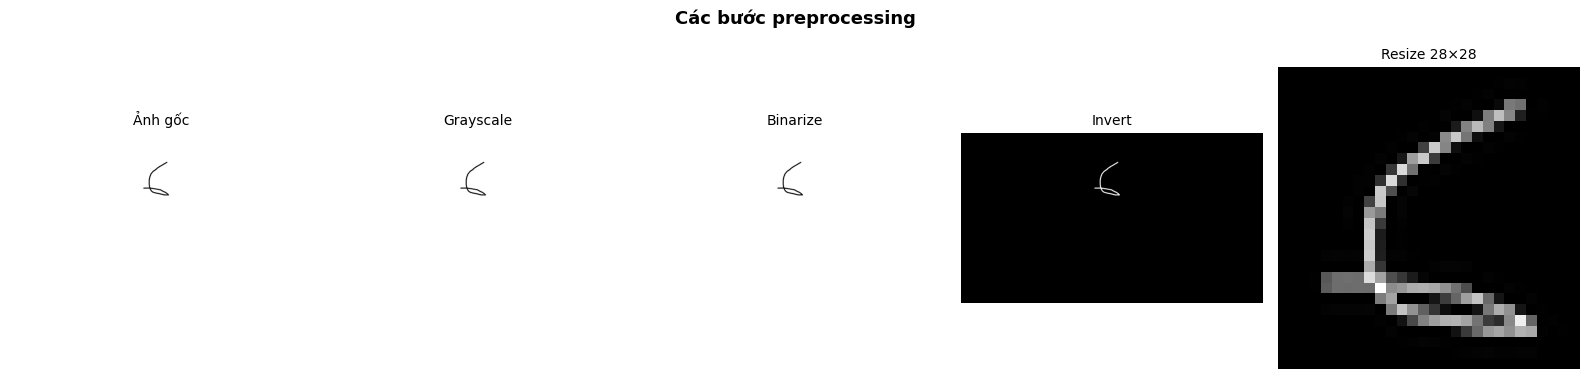

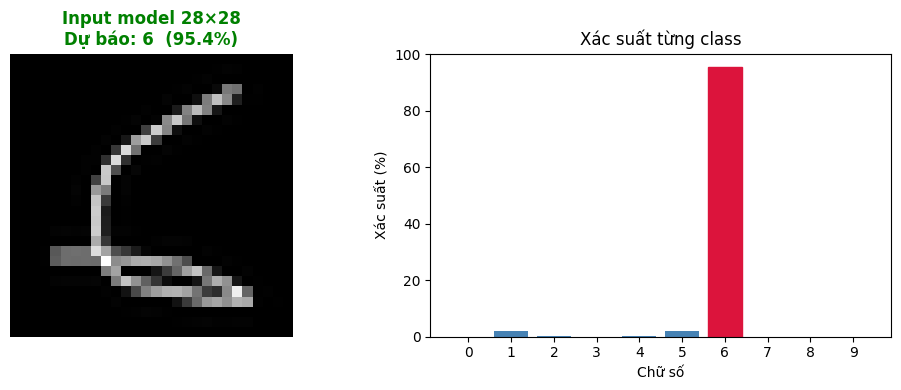

✅  Kết quả dự báo : 6
📊  Độ tin cậy     : 95.42%

Top 3 khả năng:
  1. Số 6  →  95.42%
  2. Số 1  →  2.15%
  3. Số 5  →  1.91%


In [ ]:
# ============================================================
# UPLOAD ẢNH PNG (chụp từ điện thoại) + DỰ BÁO CNN
# ============================================================
from google.colab import files
from PIL import Image, ImageOps, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import io

# ── 1. Upload file ───────────────────────────────────────────
print("📂 Chọn ảnh PNG/JPG chụp từ điện thoại...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ── 2. Mở ảnh ───────────────────────────────────────────────
img_orig = Image.open(img_path).convert('RGB')

# ── 3. Preprocessing ─────────────────────────────────────────
# Bước 1: Grayscale
img_gray = img_orig.convert('L')

# Bước 2: Làm mờ nhẹ để giảm noise (ảnh chụp điện thoại thường có noise)
img_blur = img_gray.filter(ImageFilter.GaussianBlur(radius=1))

# Bước 3: Binarize (ngưỡng 127) — chữ đen nền trắng → nhị phân
img_bin = img_blur.point(lambda p: 255 if p > 127 else 0)

# Bước 4: Invert — MNIST cần nền đen, chữ trắng
img_inv = ImageOps.invert(img_bin)

# Bước 5: Auto-crop vùng chứa chữ số (bỏ viền trắng thừa)
bbox = img_inv.getbbox()   # bounding box của vùng không đen
if bbox:
    pad = 20   # thêm padding xung quanh chữ
    left  = max(bbox[0] - pad, 0)
    upper = max(bbox[1] - pad, 0)
    right = min(bbox[2] + pad, img_inv.width)
    lower = min(bbox[3] + pad, img_inv.height)
    img_crop = img_inv.crop((left, upper, right, lower))
else:
    img_crop = img_inv

# Bước 6: Resize về 28x28
img_28 = img_crop.resize((28, 28), Image.LANCZOS)

# Bước 7: Normalize
img_arr = np.array(img_28).astype('float32') / 255.0

# ── 4. Hiển thị từng bước preprocessing ─────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
titles = ['Ảnh gốc', 'Grayscale', 'Binarize', 'Invert', 'Resize 28×28']
imgs   = [img_orig, img_gray, img_bin, img_inv, img_28]
cmaps  = [None, 'gray', 'gray', 'gray', 'gray']

for i, (ax, im, t, c) in enumerate(zip(axes, imgs, titles, cmaps)):
    ax.imshow(im, cmap=c)
    ax.set_title(t, fontsize=10)
    ax.axis('off')

plt.suptitle('Các bước preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Dự báo ────────────────────────────────────────────────
img_input   = img_arr.reshape(1, 28, 28, 1)
predictions = model.predict(img_input, verbose=0)
pred_class  = np.argmax(predictions)
confidence  = np.max(predictions) * 100

# ── 6. Hiển thị kết quả ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(img_arr, cmap='gray')
ax1.set_title(f'Input model 28×28\nDự báo: {pred_class}  ({confidence:.1f}%)',
              fontsize=12, fontweight='bold',
              color='green' if confidence >= 80 else 'orange')
ax1.axis('off')

bars = ax2.bar(range(10), predictions[0] * 100, color='steelblue')
bars[pred_class].set_color('crimson')   # highlight class được chọn
ax2.set_xticks(range(10))
ax2.set_xlabel('Chữ số')
ax2.set_ylabel('Xác suất (%)')
ax2.set_title('Xác suất từng class')

plt.tight_layout()
plt.show()

print(f'✅  Kết quả dự báo : {pred_class}')
print(f'📊  Độ tin cậy     : {confidence:.2f}%')
print()
print('Top 3 khả năng:')
top3 = np.argsort(predictions[0])[::-1][:3]
for rank, idx in enumerate(top3, 1):
    print(f'  {rank}. Số {idx}  →  {predictions[0][idx]*100:.2f}%')